
PATIENT: P01 (Ch)

===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)
✅ Loaded: Data_Ch_D.csv

===== FILE: Data_Ch_G.csv =====
K-Push:
     time   force
0  0.000  0.3873

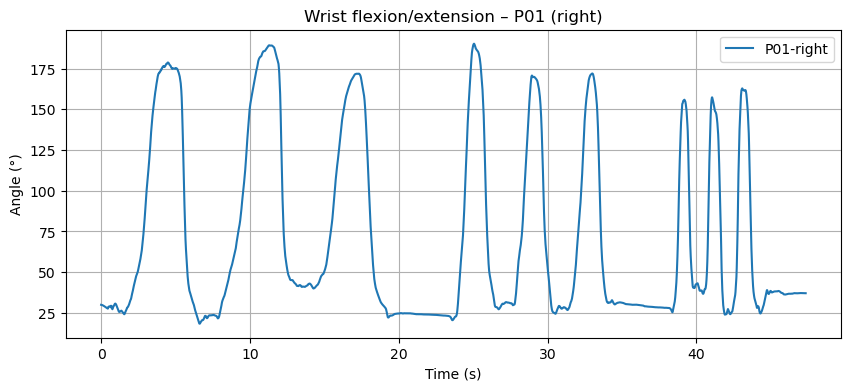

Angle range: 18.39° to 190.23°

===== P01 | LEFT =====


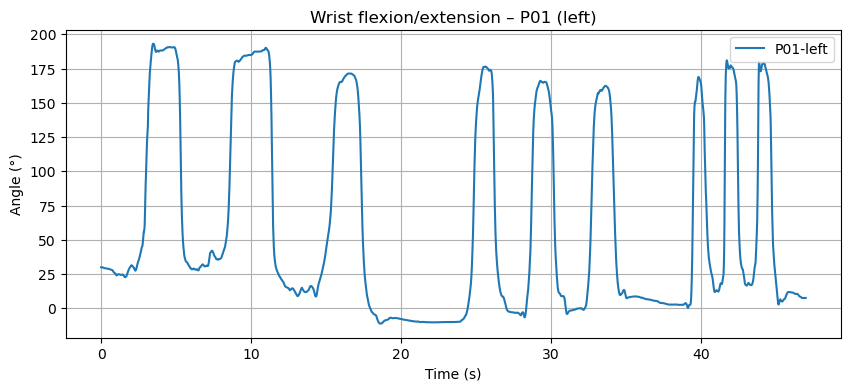

Angle range: -11.21° to 193.12°

===== P02 | RIGHT =====


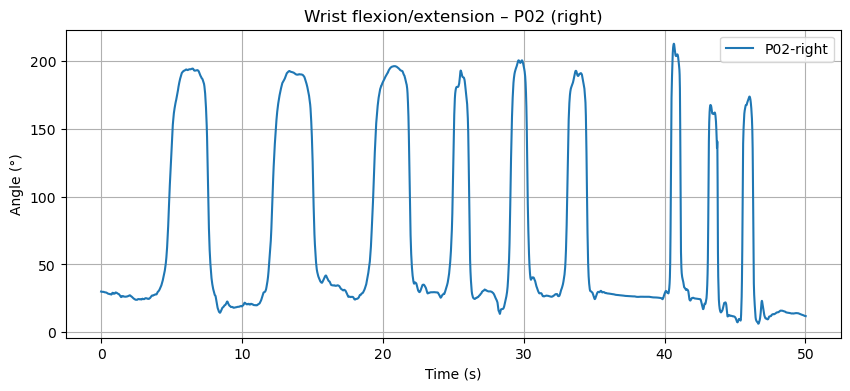

Angle range: 6.26° to 212.95°

===== P02 | LEFT =====


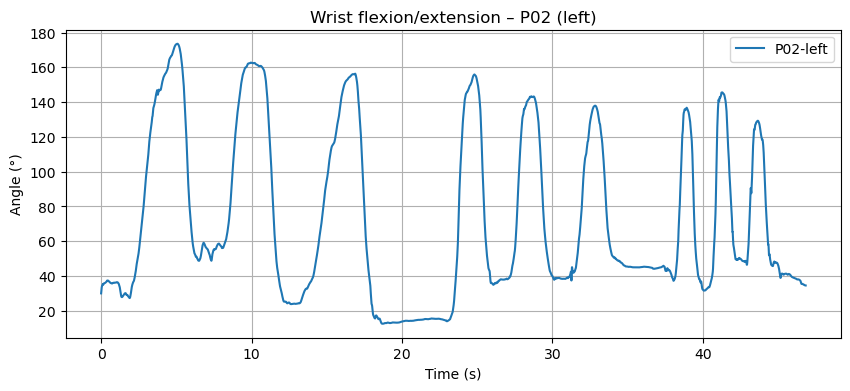

Angle range: 12.54° to 173.61°

===== P03 | RIGHT =====


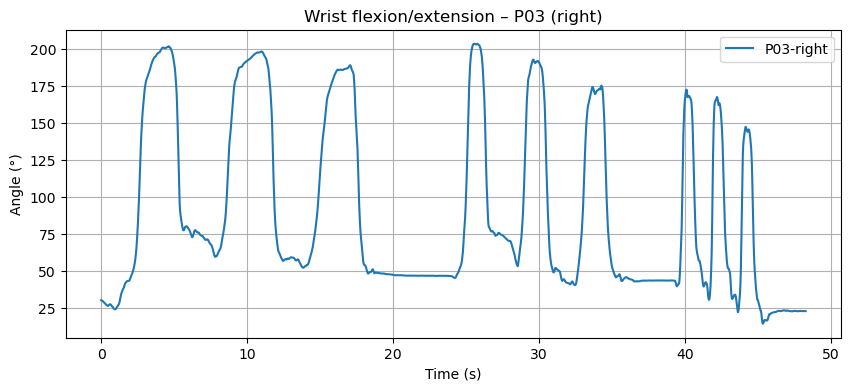

Angle range: 14.11° to 203.32°

===== P03 | LEFT =====


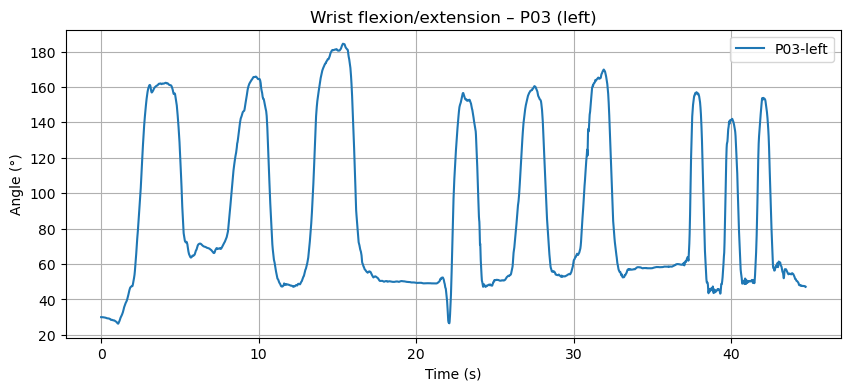

Angle range: 26.29° to 184.42°


In [95]:
# ==========================================================
# CONFIGURATION - PATIENT FILES
# ==========================================================
"""
Patient data configuration for passive elbow extension study.

Author: Anais Ragon + copilot 
Date: 21/04/2026
"""
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# ---------- PATIENT CONFIGURATION ----------
# Add your patients here following this structure
PATIENTS = {
    "P01": {
        "id": "Ch",
        "right": "Data_Ch_D.csv",
        "left": "Data_Ch_G.csv"
    

    },
    "P02": {
        "id": "Lo",
        "right": "Data_Lo_D.csv",
        "left": "Data_Lo_G.csv"
  
    },
    "P03": {
        "id": "Ca",
        "right": "Data_Ca_D.csv", 
        "left": "Data_Ca_G.csv", 
    },
}

# Acquisition frequencies
FREQ_KPUSH = 1000  # Hz
FREQ_KMOVE = 250  # Hz

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- DEBUG PRINT ----------
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# ANGLE CALCULATION
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.unwrap(np.array(angles))
    angle_deg = np.degrees(angles)

    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    angle_anatomical = angle_zeroed + baseline_deg

    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df


# ==========================================================
# CORRECTION - Multi-patients et bilatéral
# ==========================================================

results = {}

for patient_name, patient_data in PATIENTS.items():
    print(f"\n==============================")
    print(f"PATIENT: {patient_name} ({patient_data['id']})")
    print(f"==============================")

    results[patient_name] = {}

    # ✅ Corrigé : on traite droite ET gauche si présents
    for side in ["right", "left"]:
        if side not in patient_data:
            print(f"[INFO] No {side} file for {patient_name}")
            continue

        file = patient_data[side]

        try:
            df_push, df_wrist, df_shoulder, baseline = process_file(file)

            results[patient_name][side] = {
                "file": file,
                "push": df_push,
                "wrist": df_wrist,
                "shoulder": df_shoulder,
                "baseline": baseline
            }

            print(f"✅ Loaded: {file}")

        except FileNotFoundError as e:
            print(f"[WARNING] {e}")

# ==========================================================
# Processing + plotting (multi-patients, both sides)
# ==========================================================

all_angles_data = {}

for patient_name, patient_info in results.items():
    all_angles_data[patient_name] = {}

    for side, data in patient_info.items():
        print(f"\n===== {patient_name} | {side.upper()} =====")

        baseline_quat = data["baseline"]["wrist"]
        df_wrist = data["wrist"]

        if len(baseline_quat) != 4:
            print("⚠️ Missing baseline quaternion → skipped side.")
            continue

        df_angles = quaternion_to_angle_y_calibrated(
            df_wrist, baseline_quat, baseline_deg=30
        )

        all_angles_data[patient_name][side] = df_angles

        # ---------- Plot ----------
        plt.figure(figsize=(10, 4))
        plt.plot(df_angles["time"], df_angles["angle"],
                 label=f"{patient_name}-{side}")
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (°)")
        plt.title(f"Wrist flexion/extension – {patient_name} ({side})")
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"Angle range: {df_angles['angle'].min():.2f}° to {df_angles['angle'].max():.2f}°")


=== DETECTION : P01 | RIGHT ===


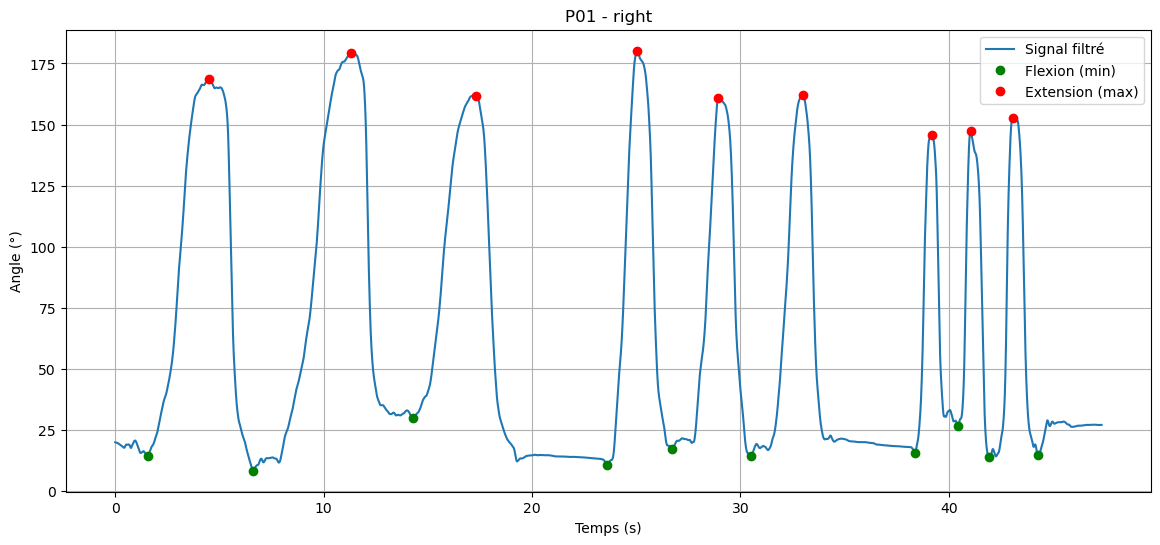


=== DETECTION : P01 | LEFT ===


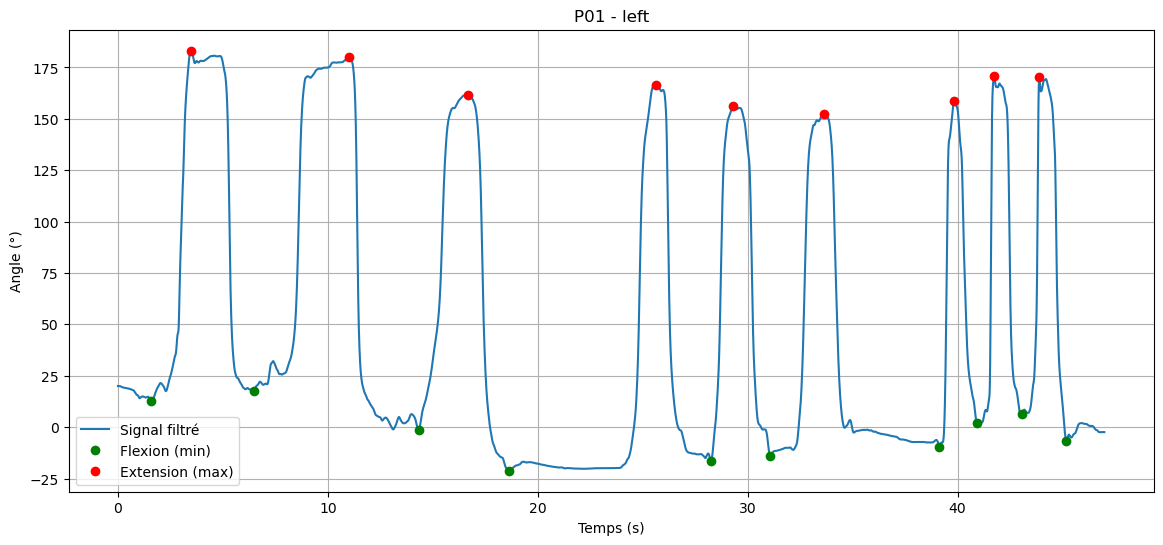


=== DETECTION : P02 | RIGHT ===


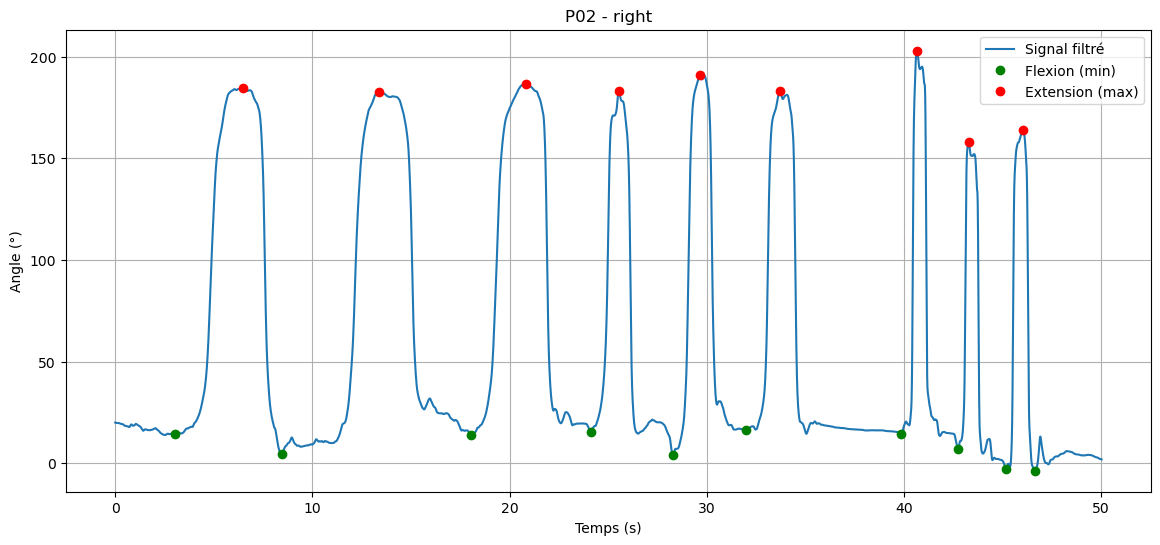


=== DETECTION : P02 | LEFT ===


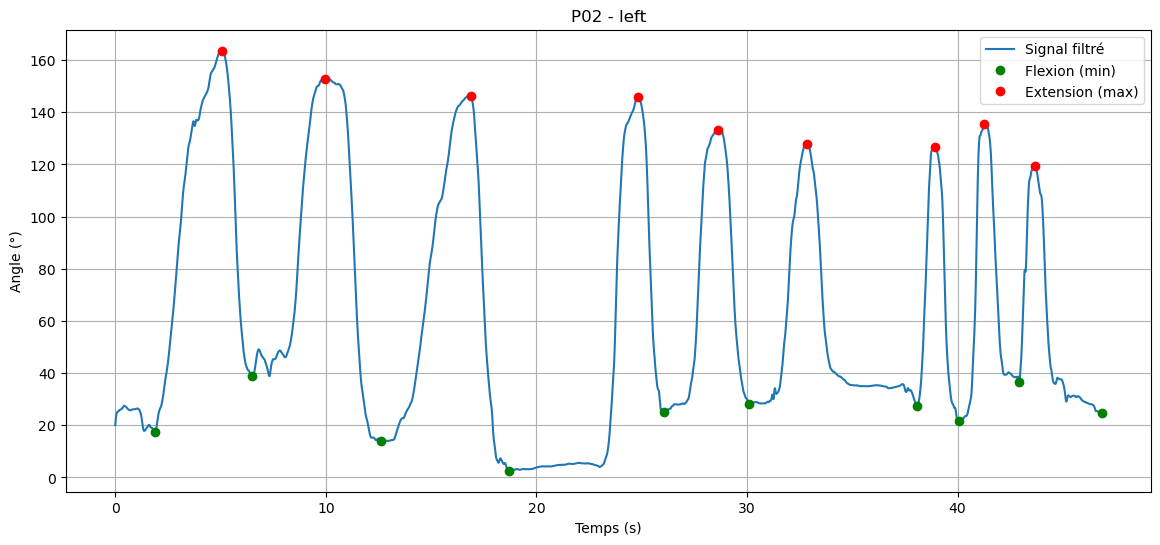


=== DETECTION : P03 | RIGHT ===


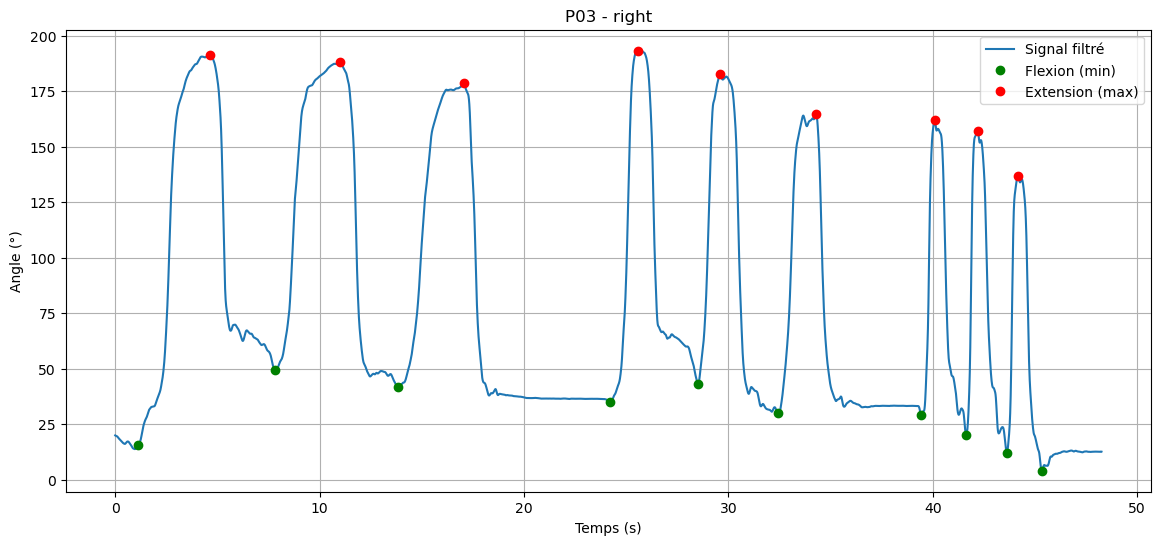


=== DETECTION : P03 | LEFT ===


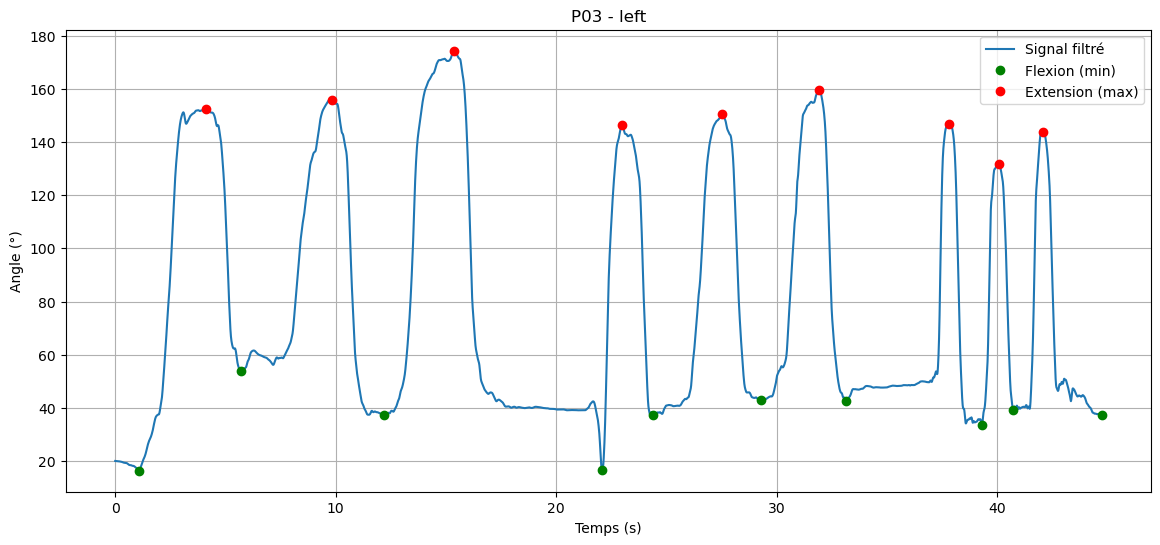


===== EVENTS: P01 | RIGHT =====
   event_id  t_start   t_end  duration   amplitude    velocity
0         1   1.5560   4.492    2.9360  154.475865   52.614395
1         2   6.6159  11.296    4.6801  170.893314   36.514885
2         3  14.2760  17.312    3.0360  131.851319   43.429288
3         4  23.6039  25.052    1.4481  169.695196  117.184722
4         5  26.7080  28.936    2.2280  143.397307   64.361448
5         6  30.5160  33.000    2.4840  147.501872   59.380786
6         7  38.3760  39.184    0.8080  130.482064  161.487703
7         8  40.4440  41.048    0.6040  120.594737  199.660161
8         9  41.9120  43.068    1.1560  138.832630  120.097431

===== EVENTS: P01 | LEFT =====
   event_id  t_start    t_end  duration   amplitude    velocity
0         1   1.5960   3.4800    1.8840  170.401217   90.446506
1         2   6.4760  10.9840    4.5080  162.395935   36.023943
2         3  14.3240  16.6640    2.3400  162.773344   69.561258
3         4  18.6159  25.6440    7.0281  187.5935

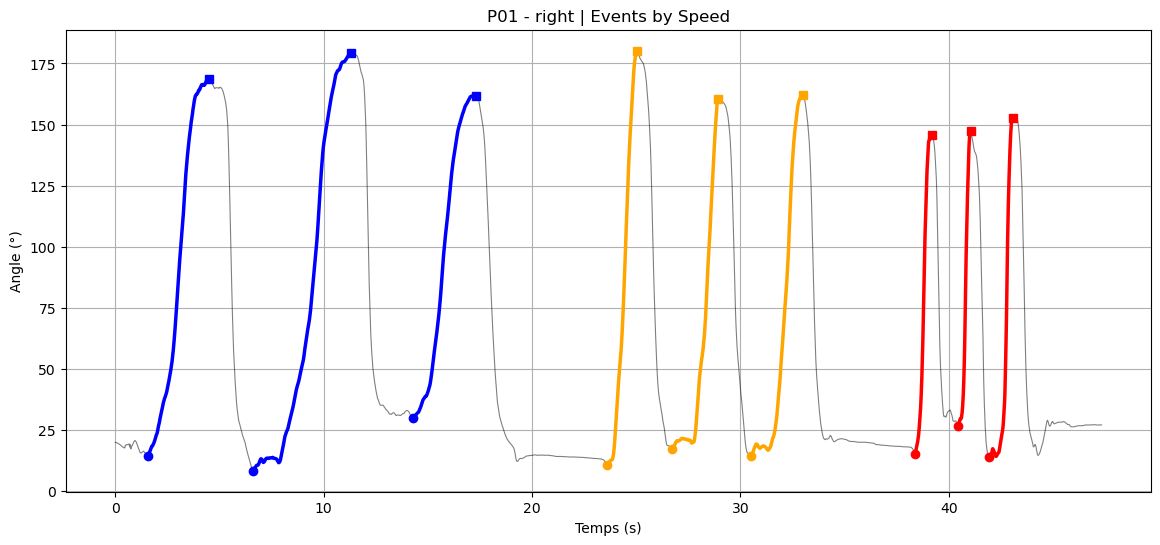


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 44.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.05 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 80.3 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.86 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 160.4 °/s

===== EVENTS: P01 | LEFT =====

TABLE - P01 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente   1.5960  3.4800    1.8840 170.401217  90.446506
        2          lente   6.4760 10.9840    4.5080 162.395935  36.023943
        3          lente  14.3240 16.6640    2.3400 162.773344  69.561258
        4        moyenne  18.6159 25.6440    7.0281 187.593545  26.691929
        5        moyenne  28.2519 29.3040    1.0521 172.604701 164.057315
        6        moyenne  31.0800 33.6280    2.5480 166.497435  65.344362
        7         rapide  39.1400 39.8480    0.7080 168.638220 238.189577
        8         rapide  4

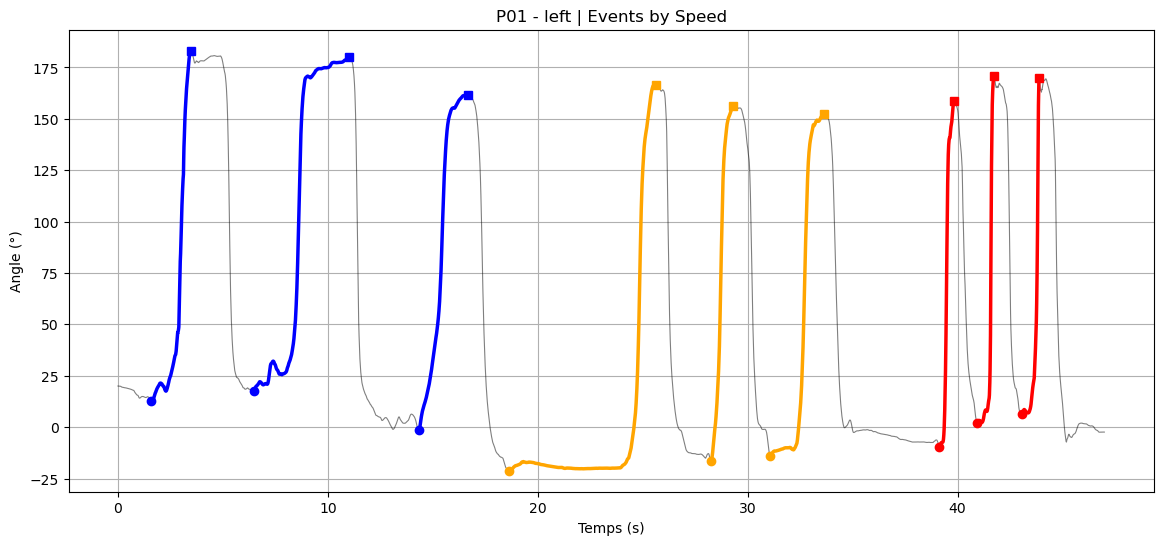


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 2.91 s
  Amplitude moyenne : 165.2°
  Vitesse moyenne   : 65.3 °/s

MOYENNE (n=3):
  Durée moyenne     : 3.54 s
  Amplitude moyenne : 175.6°
  Vitesse moyenne   : 85.4 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.78 s
  Amplitude moyenne : 166.9°
  Vitesse moyenne   : 215.1 °/s

===== EVENTS: P02 | RIGHT =====

TABLE - P02 | right
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente    3.032  6.4920    3.4600 170.218292  49.196038
        2          lente    8.432 13.3600    4.9280 178.422181  36.205800
        3          lente   18.020 20.8480    2.8280 172.268903  60.915454
        4        moyenne   24.108 25.5320    1.4240 167.598017 117.695237
        5        moyenne   28.304 29.6400    1.3360 187.132498 140.069235
        6        moyenne   31.972 33.7039    1.7319 166.778329  96.297898
        7         rapide   39.852 40.6560    0.8040 188.585051 234.558522
        8         rapide 

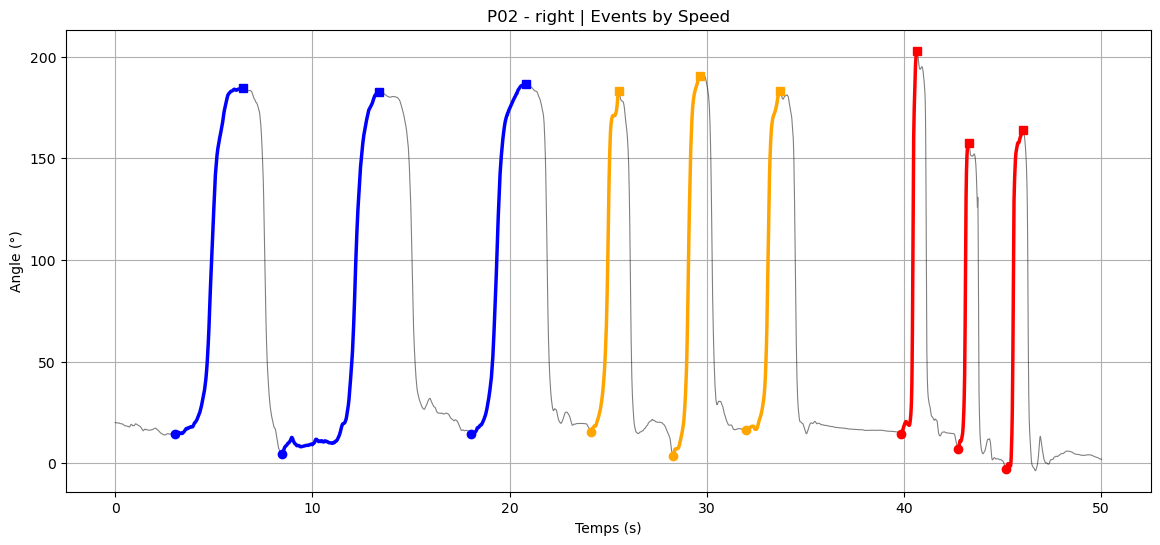


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.74 s
  Amplitude moyenne : 173.6°
  Vitesse moyenne   : 48.8 °/s

MOYENNE (n=3):
  Durée moyenne     : 1.50 s
  Amplitude moyenne : 173.8°
  Vitesse moyenne   : 118.0 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.73 s
  Amplitude moyenne : 168.6°
  Vitesse moyenne   : 237.4 °/s

===== EVENTS: P02 | LEFT =====

TABLE - P02 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente   1.8920  5.0720    3.1800 146.306258  46.008257
        2          lente   6.4920  9.9520    3.4600 114.006903  32.949972
        3          lente  12.6159 16.8800    4.2641 132.562865  31.088123
        4        moyenne  18.6880 24.8120    6.1240 143.368414  23.410910
        5        moyenne  26.0680 28.6039    2.5359 108.392109  42.743053
        6        moyenne  30.1079 32.8400    2.7321 100.075933  36.629674
        7         rapide  38.0600 38.9280    0.8680  99.512321 114.645531
        8         rapide  

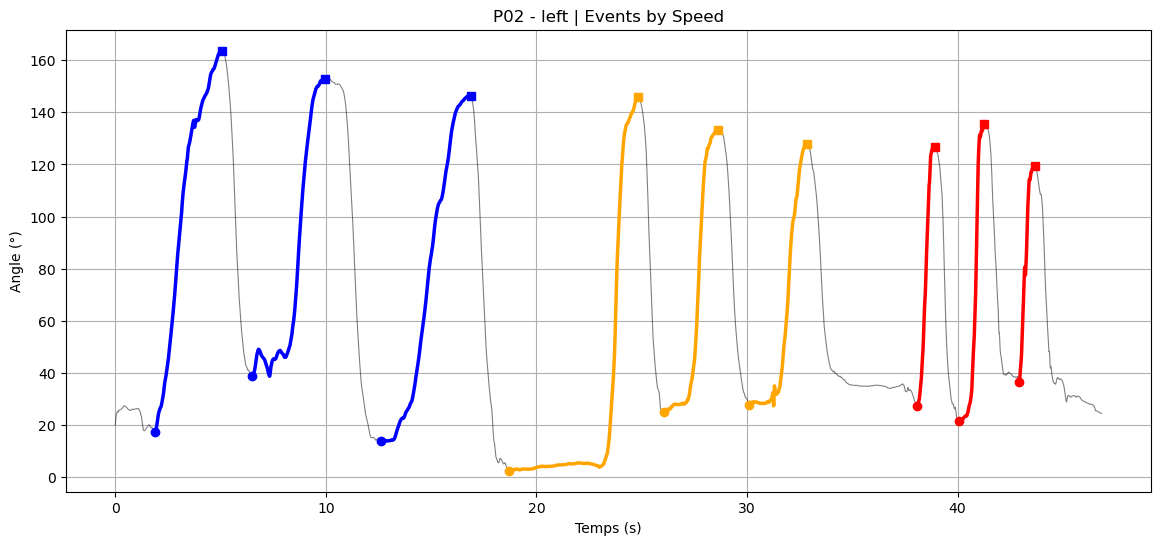


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.63 s
  Amplitude moyenne : 131.0°
  Vitesse moyenne   : 36.7 °/s

MOYENNE (n=3):
  Durée moyenne     : 3.80 s
  Amplitude moyenne : 117.3°
  Vitesse moyenne   : 34.3 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.93 s
  Amplitude moyenne : 98.8°
  Vitesse moyenne   : 107.9 °/s

===== EVENTS: P03 | RIGHT =====

TABLE - P03 | right
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente    1.124  4.628     3.504 175.775980  50.164378
        2          lente    7.820 10.988     3.168 138.794321  43.811339
        3          lente   13.848 17.052     3.204 136.845352  42.710784
        4        moyenne   24.212 25.552     1.340 158.236355 118.086832
        5        moyenne   28.524 29.588     1.064 139.516001 131.124061
        6        moyenne   32.448 34.276     1.828 134.651290  73.660443
        7         rapide   39.436 40.088     0.652 132.630963 203.421723
        8         rapide   41.632 

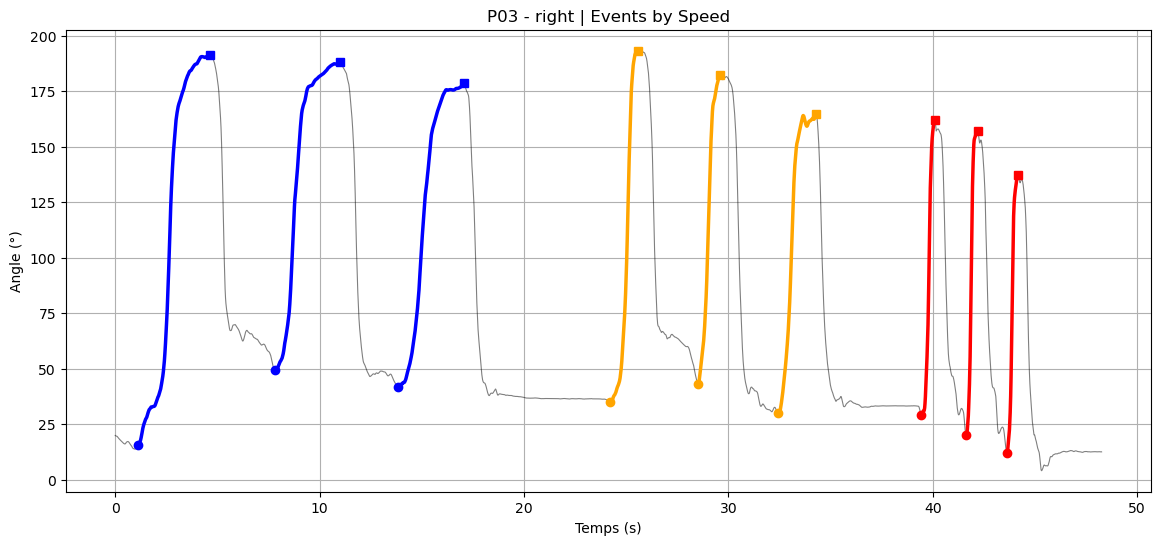


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.29 s
  Amplitude moyenne : 150.5°
  Vitesse moyenne   : 45.6 °/s

MOYENNE (n=3):
  Durée moyenne     : 1.41 s
  Amplitude moyenne : 144.1°
  Vitesse moyenne   : 107.6 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.58 s
  Amplitude moyenne : 131.6°
  Vitesse moyenne   : 229.5 °/s

===== EVENTS: P03 | LEFT =====

TABLE - P03 | left
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente    1.072  4.0960    3.0240 136.055294  44.991830
        2          lente    5.704  9.8160    4.1120 102.200965  24.854320
        3          lente   12.196 15.3600    3.1640 137.300959  43.394741
        4        moyenne   22.088 22.9800    0.8920 129.721193 145.427347
        5        moyenne   24.400 27.5239    3.1239 113.310044  36.271982
        6        moyenne   29.300 31.9120    2.6120 116.925855  44.764875
        7         rapide   33.144 37.8080    4.6640 104.492479  22.404048
        8         rapide  

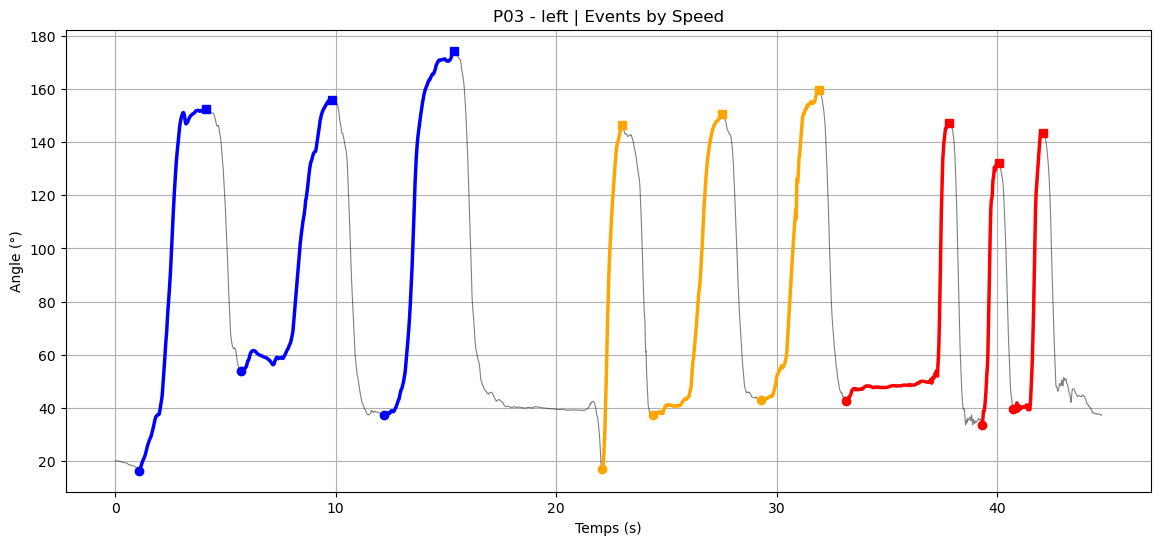


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.43 s
  Amplitude moyenne : 125.2°
  Vitesse moyenne   : 37.7 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.21 s
  Amplitude moyenne : 120.0°
  Vitesse moyenne   : 75.5 °/s

RAPIDE (n=3):
  Durée moyenne     : 2.26 s
  Amplitude moyenne : 102.4°
  Vitesse moyenne   : 76.6 °/s


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMÈTRES
# ==========================================================
N_MAX = 9
N_MIN = 10
MIN_PROM = 15
MIN_DIST_SEC = 1.5
FILTER_CUTOFF = 10

# ==========================================================
# FILTRE
# ==========================================================
def butter_lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cut = min(cutoff / nyq, 0.99)
    b, a = butter(order, normal_cut, btype='low')
    return filtfilt(b, a, signal)

# ==========================================================
# DÉTECTION DES ÉVÉNEMENTS
# ==========================================================
def detect_clean_events(df_angles):

    time = df_angles["time"].values
    angle = df_angles["angle"].values
    fs = 1 / np.mean(np.diff(time))

    # ---------- FILTRAGE ----------
    signal_f = butter_lowpass_filter(angle, FILTER_CUTOFF, fs)

    # ---------- MAXIMA ----------
    dist_samples = int(fs * MIN_DIST_SEC)
    raw_max, _ = find_peaks(signal_f, distance=dist_samples, prominence=MIN_PROM)

    if len(raw_max) > N_MAX:
        idx = np.argsort(signal_f[raw_max])[::-1]
        raw_max = raw_max[idx[:N_MAX]]

    raw_max = np.sort(raw_max)

    # ---------- MINIMA ROBUSTES ----------
    minima = []

    # --- avant premier max ---
    if len(raw_max) > 0:
        first_max = raw_max[0]
        start = int(max(0, first_max - 3.5 * fs))
        segment = signal_f[start:first_max]

        if len(segment) > 5:
            minima.append(start + np.argmin(segment))

    # --- entre chaque max ---
    for i in range(len(raw_max) - 1):
        left = raw_max[i]
        right = raw_max[i + 1]

        segment = signal_f[left:right]
        if len(segment) > 5:
            minima.append(left + np.argmin(segment))

    # --- après dernier max ---
    if len(raw_max) > 0:
        last_max = raw_max[-1]
        segment = signal_f[last_max:]

        if len(segment) > 5:
            minima.append(last_max + np.argmin(segment))

    minima = np.array(minima, dtype=int)

    # ---------- GARANTIES ----------
    minima = np.unique(minima)

    if len(minima) > N_MIN:
        minima = minima[:N_MIN]
    elif len(minima) < N_MIN and len(minima) > 0:
        minima = np.pad(minima, (0, N_MIN - len(minima)), mode='edge')

    return minima, raw_max, signal_f

# ==========================================================
# PLOT + STOCKAGE
# ==========================================================
def plot_and_store(df_angles, minima, maxima, signal_f, patient_name, side, events_results):

    events_results.setdefault(patient_name, {})

    events_results[patient_name][side] = {
        "angles": df_angles,
        "signal_filtered": signal_f,
        "peaks_flexion": minima,
        "peaks_extension": maxima
    }

    time = df_angles["time"].values

    plt.figure(figsize=(14, 6))
    plt.plot(time, signal_f, label="Signal filtré")

    if len(minima) > 0:
        plt.plot(time[minima], signal_f[minima], "go", label="Flexion (min)")

    if len(maxima) > 0:
        plt.plot(time[maxima], signal_f[maxima], "ro", label="Extension (max)")

    plt.title(f"{patient_name} - {side}")
    plt.xlabel("Temps (s)")
    plt.ylabel("Angle (°)")
    plt.legend()
    plt.grid()
    plt.show()

# ==========================================================
# DÉTECTION MULTI-PATIENTS
# ==========================================================
events_results = {}

for patient_name, pdata in results.items():
    for side, data in pdata.items():

        print(f"\n=== DETECTION : {patient_name} | {side.upper()} ===")

        df = data["wrist"]
        baseline = data["baseline"]["wrist"]

        df_angles = quaternion_to_angle_y_calibrated(df, baseline, baseline_deg=20)

        minima, maxima, signal_f = detect_clean_events(df_angles)

        plot_and_store(df_angles, minima, maxima, signal_f,
                       patient_name, side, events_results)

# ==========================================================
# ANALYSE DES ÉVÉNEMENTS
# ==========================================================
all_events_summary = {}

for patient_name in events_results:

    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data = events_results[patient_name][side]

        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        events = []

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):

            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]

            t_start = time[min_idx]
            t_end = time[max_idx]

            duration = t_end - t_start
            amplitude = signal[max_idx] - signal[min_idx]
            velocity = amplitude / duration if duration > 0 else 0

            events.append({
                "event_id": i + 1,
                "t_start": t_start,
                "t_end": t_end,
                "duration": duration,
                "amplitude": amplitude,
                "velocity": velocity
            })

        df_events = pd.DataFrame(events)
        all_events_summary[patient_name][side] = df_events

        print(df_events)

# ==========================================================
# EVENTS ANALYSIS (MULTI-PATIENTS)
# ==========================================================
all_events_summary = {}

for patient_name in events_results:

    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data = events_results[patient_name][side]

        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        # ---------- 1. EVENTS ----------
        events = []

        if len(peaks_flexion) < 2 or len(peaks_extension) == 0:
            print("⚠️ Pas assez de pics pour créer des événements")
            continue

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):

            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]

            t_start = time[min_idx]
            t_end = time[max_idx]
            duration = t_end - t_start

            angle_start = signal[min_idx]
            angle_end = signal[max_idx]
            amplitude = angle_end - angle_start

            velocity = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id': i + 1,
                'min_idx': min_idx,
                'max_idx': max_idx,
                't_start': t_start,
                't_end': t_end,
                'duration': duration,
                'angle_start': angle_start,
                'angle_end': angle_end,
                'amplitude': amplitude,
                'velocity': velocity
            })

        # ---------- 2. CLASSIFICATION ----------
        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3

        for i, event in enumerate(events):
            event['speed_category'] = speed_labels[i] if i < len(speed_labels) else 'extra'

        df_events = pd.DataFrame(events)

        all_events_summary[patient_name][side] = df_events

        # ---------- 3. TABLE ----------
        print("\n" + "="*60)
        print(f"TABLE - {patient_name} | {side}")
        print("="*60)

        if not df_events.empty:
            print(df_events[['event_id', 'speed_category',
                             't_start', 't_end',
                             'duration', 'amplitude', 'velocity']].to_string(index=False))
        else:
            print("Aucun événement détecté")

        # ---------- 4. PLOT ----------
        colors_speed = {
            'lente': 'blue',
            'moyenne': 'orange',
            'rapide': 'red',
            'extra': 'gray'
        }

        plt.figure(figsize=(14,6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)

        for event in events:
            color = colors_speed[event['speed_category']]

            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)

            plt.plot(time[idx_range], signal[idx_range],
                     color=color, linewidth=2.5)

            plt.plot(time[event['min_idx']], signal[event['min_idx']],
                     'o', color=color)

            plt.plot(time[event['max_idx']], signal[event['max_idx']],
                     's', color=color)

        plt.title(f"{patient_name} - {side} | Events by Speed")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.show()

        # ---------- 5. STATS ----------
        print("\nSTATISTIQUES :")

        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]

            if len(subset) == 0:
                continue

            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, find_peaks

# ==========================================================
# PARAMETERS
# ==========================================================
N_MAX             = 9
N_MIN             = 10
MIN_PROM          = 15
MIN_DIST_SEC      = 1.5
FILTER_CUTOFF     = 10

PAUSE_VEL_THRESHOLD  = 2.0   # °/s
PAUSE_MIN_DURATION   = 2.0   # s

# ==========================================================
# NOTE FOR THE USER
# ==========================================================
# After running the full detection pipeline (your existing code),
# fill in the MANUAL_CORRECTIONS dictionary below.
#
# Structure:
#   MANUAL_CORRECTIONS = {
#       "P01": {
#           "right": [2, 5],      # event_ids to REMOVE for P01 right
#           "left":  []           # nothing to remove for P01 left
#       },
#       "P02": {
#           "right": [7],
#           "left":  [3, 8]
#       },
#   }
#
# How to find the wrong event_ids:
#   → Look at the "Events by speed" plots produced by your detection code.
#   → Identify the event numbers (event_id column in the printed table)
#     where the green dot (onset) is clearly too early (inside the pause).
#   → Write those ids here, one list per patient/side.

MANUAL_CORRECTIONS = {
    "P01": {"right": [2], "left": [2,4]},
    "P02": {"right": [2], "left": [4]},
    "P03": {"right": [6], "left": [3,7]},

}

# ==========================================================
# STEP 1 — APPLY MANUAL CORRECTIONS
# ==========================================================
def apply_manual_corrections(all_events_summary, corrections):
    """
    Remove manually identified erroneous events from all_events_summary.

    Parameters
    ----------
    all_events_summary : dict  – output of the detection pipeline
    corrections        : dict  – MANUAL_CORRECTIONS defined above

    Returns
    -------
    cleaned : dict – same structure, with bad events removed and
                     event_id re-numbered from 1
    """
    cleaned = {}

    for patient_name, sides in all_events_summary.items():
        cleaned[patient_name] = {}

        for side, df_events in sides.items():
            ids_to_remove = corrections.get(patient_name, {}).get(side, [])

            if ids_to_remove:
                print(f"  [{patient_name} | {side}] Removing event_ids: {ids_to_remove}")
                df_clean = df_events[~df_events["event_id"].isin(ids_to_remove)].copy()
            else:
                df_clean = df_events.copy()

            # Re-number event_id from 1 after removal
            df_clean = df_clean.reset_index(drop=True)
            df_clean["event_id"] = df_clean.index + 1

            cleaned[patient_name][side] = df_clean

    return cleaned

print("\n" + "="*60)
print("STEP 1 — APPLYING MANUAL CORRECTIONS")
print("="*60)

# all_events_summary must already exist from your detection pipeline
all_events_clean = apply_manual_corrections(all_events_summary, MANUAL_CORRECTIONS)


STEP 1 — APPLYING MANUAL CORRECTIONS
  [P01 | right] Removing event_ids: [2]
  [P01 | left] Removing event_ids: [2, 4]
  [P02 | right] Removing event_ids: [2]
  [P02 | left] Removing event_ids: [4]
  [P03 | right] Removing event_ids: [6]
  [P03 | left] Removing event_ids: [3, 7]


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import butter, filtfilt, find_peaks


# ==========================================================
# STEP 2 — FULL DATA TABLE (all patients, both sides)
# ==========================================================
print("\n" + "="*60)
print("STEP 2 — FULL DATA TABLE")
print("="*60)

rows_full = []

for patient_name, sides in all_events_clean.items():
    patient_id = PATIENTS[patient_name]["id"]

    for side, df_events in sides.items():
        for _, row in df_events.iterrows():
            rows_full.append({
                "patient"       : patient_name,
                "patient_id"    : patient_id,
                "side"          : side,
                "event_id"      : int(row["event_id"]),
                "speed_category": row["speed_category"],
                "t_start"       : round(row["t_start"], 3),
                "t_end"         : round(row["t_end"], 3),
                "duration"      : round(row["duration"], 3),
                "angle_start"   : round(row["angle_start"], 2),
                "angle_end"     : round(row["angle_end"], 2),
                "amplitude"     : round(row["amplitude"], 2),
                "velocity"      : round(row["velocity"], 2),
            })

df_full = pd.DataFrame(rows_full)

print("\nFULL EVENT TABLE (all patients, both sides):")
print(df_full.to_string(index=False))


STEP 2 — FULL DATA TABLE

FULL EVENT TABLE (all patients, both sides):
patient patient_id  side  event_id speed_category  t_start  t_end  duration  angle_start  angle_end  amplitude  velocity
    P01         Ch right         1          lente    1.556  4.492     2.936        14.22     168.69     154.48     52.61
    P01         Ch right         2          lente   14.276 17.312     3.036        30.00     161.85     131.85     43.43
    P01         Ch right         3        moyenne   23.604 25.052     1.448        10.53     180.23     169.70    117.18
    P01         Ch right         4        moyenne   26.708 28.936     2.228        17.26     160.65     143.40     64.36
    P01         Ch right         5        moyenne   30.516 33.000     2.484        14.47     161.97     147.50     59.38
    P01         Ch right         6         rapide   38.376 39.184     0.808        15.40     145.88     130.48    161.49
    P01         Ch right         7         rapide   40.444 41.048     0.604      

In [99]:
# ==========================================================
# STEP 3 — MEAN VELOCITY TABLE per patient / side / speed
# ==========================================================
print("\n" + "="*60)
print("STEP 3 — MEAN VELOCITY TABLE")
print("="*60)

df_means = (
    df_full
    .groupby(["patient", "patient_id", "side", "speed_category"])
    .agg(
        n_events        = ("event_id",  "count"),
        mean_duration   = ("duration",  "mean"),
        mean_amplitude  = ("amplitude", "mean"),
        mean_velocity   = ("velocity",  "mean"),
        std_velocity    = ("velocity",  "std"),
    )
    .round(2)
    .reset_index()
)

print("\nMEAN VELOCITY TABLE:")
print(df_means.to_string(index=False))




STEP 3 — MEAN VELOCITY TABLE

MEAN VELOCITY TABLE:
patient patient_id  side speed_category  n_events  mean_duration  mean_amplitude  mean_velocity  std_velocity
    P01         Ch  left          lente         2           2.11          166.58          80.00         14.77
    P01         Ch  left        moyenne         2           1.80          169.55         114.70         69.81
    P01         Ch  left         rapide         3           0.78          166.88         215.10         21.09
    P01         Ch right          lente         2           2.99          143.16          48.02          6.49
    P01         Ch right        moyenne         3           2.05          153.53          80.31         32.03
    P01         Ch right         rapide         3           0.86          129.97         160.42         39.79
    P02         Lo  left          lente         3           3.63          130.96          36.68          8.13
    P02         Lo  left        moyenne         2           2.63    


STEP 4 — REPRODUCIBILITY PLOTS


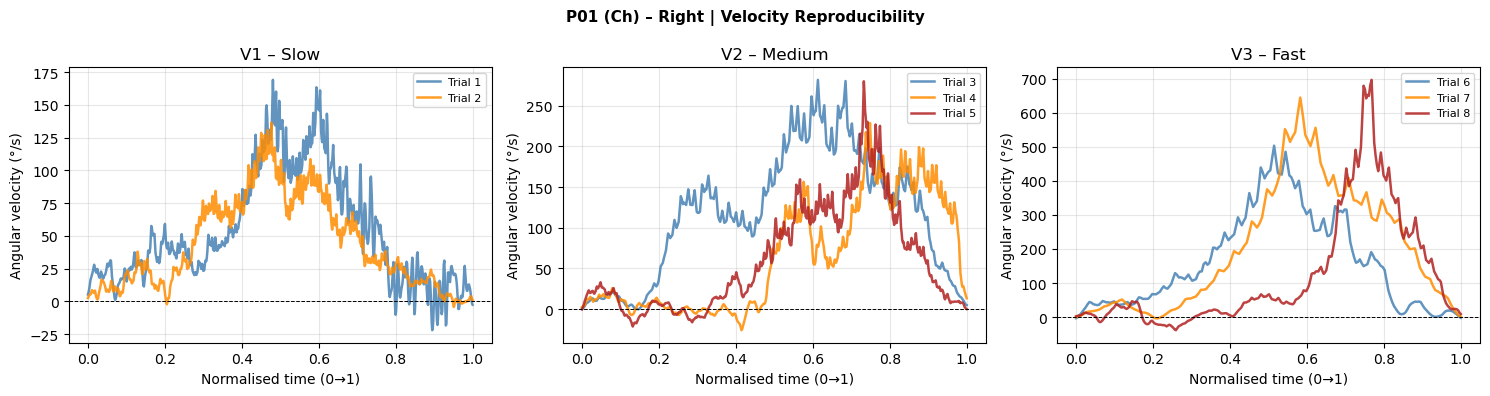

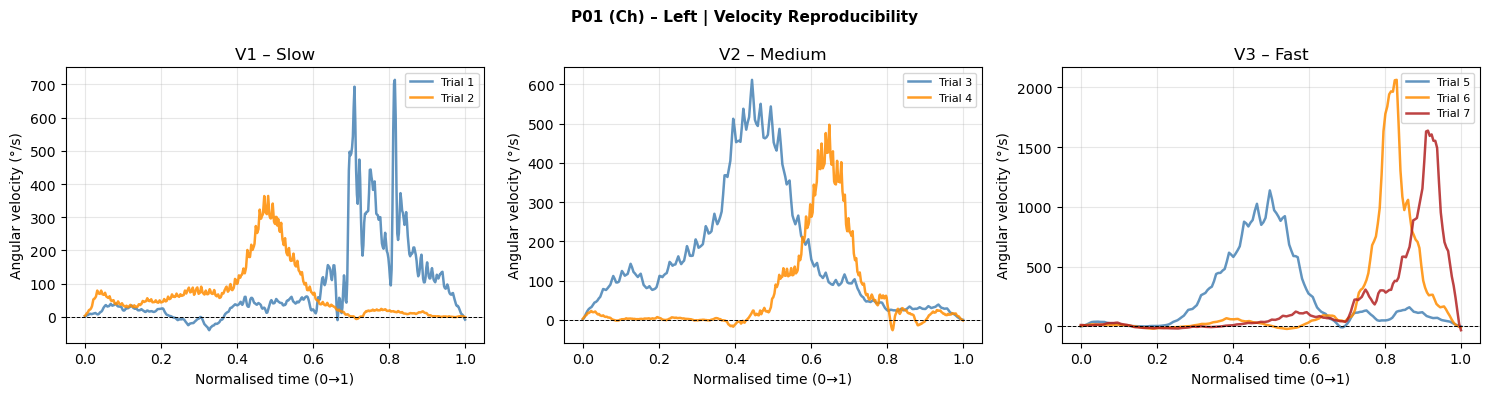

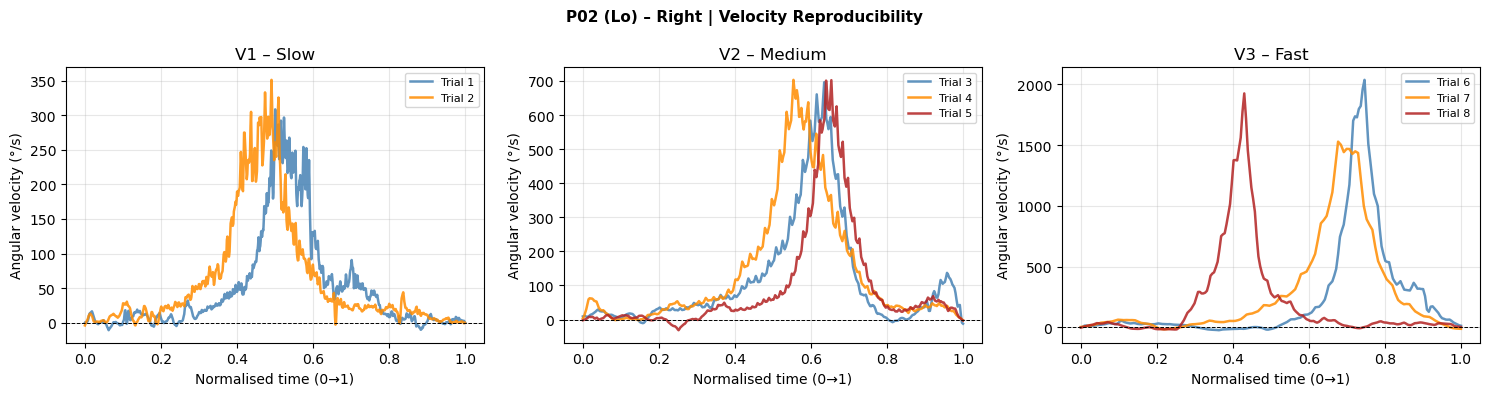

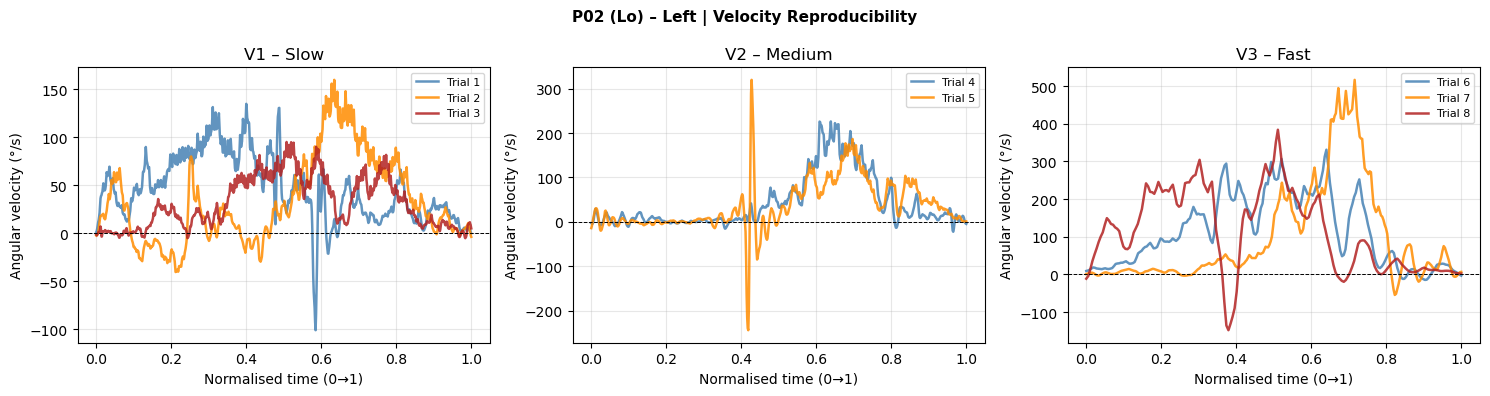

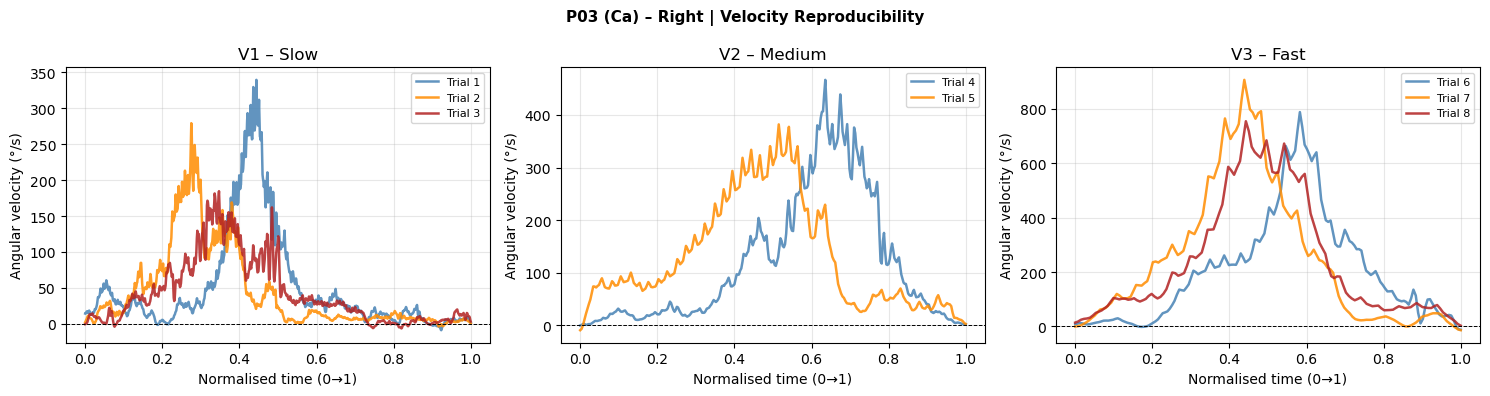

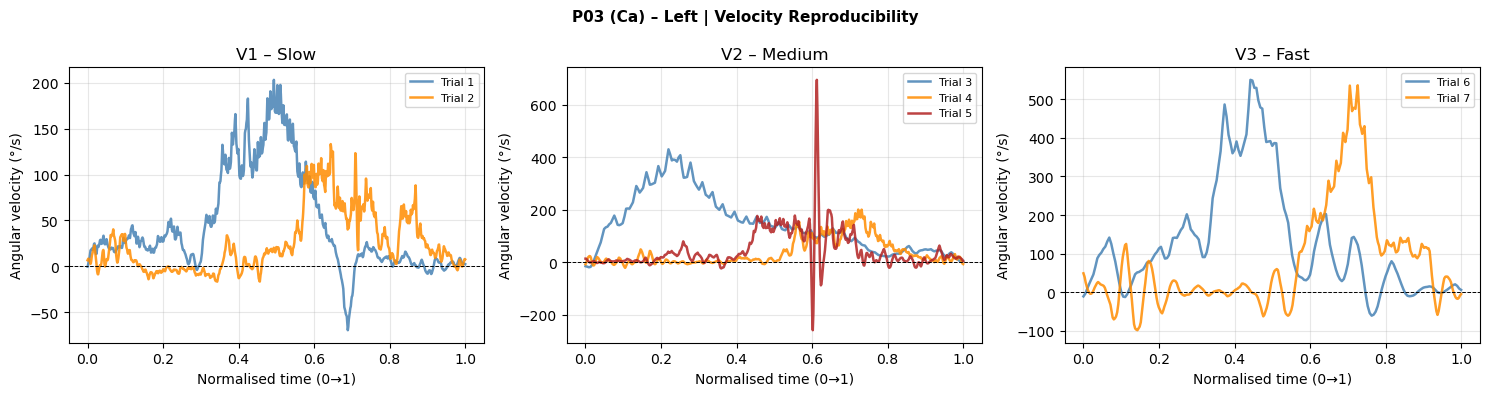

In [100]:
# ==========================================================
# STEP 4 — REPRODUCIBILITY PLOT (velocity profiles)
# ==========================================================
print("\n" + "="*60)
print("STEP 4 — REPRODUCIBILITY PLOTS")
print("="*60)

def extract_event_signal(df_angles, t_start, t_end):
    """
    Extract and normalise the angle and velocity profile of one event.

    Time is normalised to [0, 1] so that trials of different durations
    can be overlaid on the same axes (cycle-normalisation).

    Parameters
    ----------
    df_angles : pd.DataFrame – columns 'time' and 'angle'
    t_start   : float        – event start time (s)
    t_end     : float        – event end time (s)

    Returns
    -------
    t_norm   : np.ndarray – normalised time [0, 1]
    angle    : np.ndarray – angle (°)
    velocity : np.ndarray – angular velocity (°/s), computed by np.gradient
    """
    mask       = (df_angles["time"] >= t_start) & (df_angles["time"] <= t_end)
    df_segment = df_angles.loc[mask].copy()

    if len(df_segment) < 2:
        return None, None, None

    t = df_segment["time"].values
    if t[-1] == t[0]:
        return None, None, None

    t_norm   = (t - t[0]) / (t[-1] - t[0])
    angle    = df_segment["angle"].values
    velocity = np.gradient(angle, t)   # °/s

    return t_norm, angle, velocity


def plot_reproducibility_patient(all_events_clean, all_angles_data,
                                  patient_name, side):
    """
    Plot velocity profiles for all clean events, grouped by speed category.

    Each subplot shows the 3 trials of one speed condition overlaid,
    with time normalised to [0, 1]. This allows visual assessment of
    intra-speed reproducibility (consistent peak timing and amplitude).

    Parameters
    ----------
    all_events_clean : dict – cleaned events summary
    all_angles_data  : dict – angle time-series per patient/side
    patient_name     : str
    side             : str  – 'right' or 'left'
    """
    if side not in all_events_clean.get(patient_name, {}):
        return
    if side not in all_angles_data.get(patient_name, {}):
        return

    df_events = all_events_clean[patient_name][side]
    df_angles = all_angles_data[patient_name][side]

    speed_order  = ["slow", "medium", "fast",
                    "lente", "moyenne", "rapide"]   # accept both languages
    speed_titles = {
        "slow": "V1 – Slow", "lente": "V1 – Slow",
        "medium": "V2 – Medium", "moyenne": "V2 – Medium",
        "fast": "V3 – Fast", "rapide": "V3 – Fast",
    }

    present_speeds = [s for s in speed_order
                      if s in df_events["speed_category"].values]
    present_speeds = list(dict.fromkeys(present_speeds))   # deduplicate, keep order

    if not present_speeds:
        print(f"  No events for {patient_name} {side}")
        return

    fig, axes = plt.subplots(1, len(present_speeds),
                              figsize=(5 * len(present_speeds), 4))
    if len(present_speeds) == 1:
        axes = [axes]

    colors = ["steelblue", "darkorange", "firebrick"]

    for ax, speed in zip(axes, present_speeds):
        subset = df_events[df_events["speed_category"] == speed]

        for j, (_, event) in enumerate(subset.iterrows()):
            t_norm, angle, velocity = extract_event_signal(
                df_angles, event["t_start"], event["t_end"]
            )
            if t_norm is None:
                continue

            color = colors[j % len(colors)]
            ax.plot(t_norm, velocity,
                    label=f"Trial {int(event['event_id'])}",
                    color=color, linewidth=1.8, alpha=0.85)

        ax.axhline(y=0, linestyle="--", linewidth=0.7, color="black")
        ax.set_title(speed_titles.get(speed, speed))
        ax.set_xlabel("Normalised time (0→1)")
        ax.set_ylabel("Angular velocity (°/s)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    patient_id = PATIENTS[patient_name]["id"]
    fig.suptitle(f"{patient_name} ({patient_id}) – {side.capitalize()} "
                 f"| Velocity Reproducibility",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Run for all patients and sides
for patient_name in all_events_clean:
    for side in all_events_clean[patient_name]:
        plot_reproducibility_patient(
            all_events_clean, all_angles_data, patient_name, side
        )



In [101]:
# ==========================================================
# STEP 5 — EXPORT TABLE FOR R (ICC analysis)
# ==========================================================
print("\n" + "="*60)
print("STEP 5 — EXPORT FOR R (ICC)")
print("="*60)

# Wide format: one row per patient/side, one column per trial velocity
# This is the format expected by irr::icc() or psych::ICC() in R.
#
# Example R code to compute ICC:
#   library(irr)
#   df <- read.csv("icc_export.csv")
#   # Select columns for the speed you want, e.g. slow:
#   slow_cols <- df[, grep("slow_trial", names(df))]
#   icc(slow_cols, model="twoway", type="agreement", unit="average")

icc_rows = []

for patient_name, sides in all_events_clean.items():
    patient_id = PATIENTS[patient_name]["id"]

    for side, df_events in sides.items():
        row = {
            "patient"   : patient_name,
            "patient_id": patient_id,
            "side"      : side,
        }

        # For each speed category, spread trial velocities into separate columns
        for speed in ["slow", "medium", "fast",
                      "lente", "moyenne", "rapide"]:
            subset = df_events[df_events["speed_category"] == speed]

            # Normalise speed label to English for column names
            speed_en = {"lente": "slow", "moyenne": "medium",
                        "rapide": "fast"}.get(speed, speed)

            for trial_num, (_, event) in enumerate(subset.iterrows(), start=1):
                col = f"{speed_en}_trial{trial_num}_velocity"
                row[col] = round(event["velocity"], 2)

        icc_rows.append(row)

df_icc = pd.DataFrame(icc_rows)

# Save to CSV
output_path = "icc_export.csv"
df_icc.to_csv(output_path, index=False)
print(f"\n✅ ICC table saved → {output_path}")
print(df_icc.to_string(index=False))

print("\n--- R code to use this file ---")
print("""
library(irr)
df <- read.csv("icc_export.csv")

# Example: ICC on slow-speed trials
slow_data <- df[, grep("slow_trial.*velocity", names(df))]
slow_data <- slow_data[complete.cases(slow_data), ]
icc(slow_data, model = "twoway", type = "agreement", unit = "average")

# Repeat for medium and fast:
# medium_data <- df[, grep("medium_trial.*velocity", names(df))]
# fast_data   <- df[, grep("fast_trial.*velocity",   names(df))]
""")

# ==========================================================
# STEP 6 — SUMMARY PRINT
# ==========================================================
print("\n" + "="*60)
print("STEP 6 — FINAL SUMMARY")
print("="*60)
print(f"\nTotal events after correction : {len(df_full)}")
print(f"Patients                      : {df_full['patient'].nunique()}")
print(f"Sides                         : {df_full['side'].unique().tolist()}")
print(f"\nMean velocity by speed:")
print(
    df_means.groupby("speed_category")[["mean_velocity", "std_velocity"]]
    .mean()
    .round(2)
    .to_string()
)


STEP 5 — EXPORT FOR R (ICC)

✅ ICC table saved → icc_export.csv
patient patient_id  side  slow_trial1_velocity  slow_trial2_velocity  medium_trial1_velocity  medium_trial2_velocity  medium_trial3_velocity  fast_trial1_velocity  fast_trial2_velocity  fast_trial3_velocity  slow_trial3_velocity
    P01         Ch right                 52.61                 43.43                  117.18                   64.36                   59.38                161.49                199.66                120.10                   NaN
    P01         Ch  left                 90.45                 69.56                  164.06                   65.34                     NaN                238.19                210.25                196.85                   NaN
    P02         Lo right                 49.20                 60.92                  117.70                  140.07                   96.30                234.56                283.10                194.67                   NaN
    P02         Lo 

In [102]:
# ==========================================================
# BUILD SIMPLE SUMMARY TABLE FOR R (per patient/side/speed)
# ==========================================================

# On part de df_means déjà calculé ci-dessus
# (il contient mean_duration, mean_amplitude, mean_velocity, etc.)

summary_for_R = (
    df_means
    .pivot_table(index=["patient", "patient_id", "side"],
                 columns="speed_category",
                 values="mean_velocity")
    .reset_index()
)

# Renommer les colonnes pour plus de clarté
summary_for_R = summary_for_R.rename(columns={
    "lente": "mean_velocity_slow",
    "moyenne": "mean_velocity_medium",
    "rapide": "mean_velocity_fast"
})

# Arrondir pour une lecture propre
summary_for_R = summary_for_R.round(2)

print("\n========== SUMMARY TABLE FOR R ==========")
print(summary_for_R.to_string(index=False))

# ==========================================================
# EXPORT TO CSV
# ==========================================================
output_path = "velocity_summary_for_R.csv"
summary_for_R.to_csv(output_path, index=False)

print(f"\n✅ CSV exporté : {output_path}")



========== SUMMARY TABLE FOR R ==========
patient patient_id  side  mean_velocity_slow  mean_velocity_medium  mean_velocity_fast
    P01         Ch  left               80.00                114.70              215.10
    P01         Ch right               48.02                 80.31              160.42
    P02         Lo  left               36.68                 39.68              107.90
    P02         Lo right               55.06                118.02              237.44
    P03         Ca  left               34.92                 75.49              103.66
    P03         Ca right               45.56                124.60              229.52

✅ CSV exporté : velocity_summary_for_R.csv


In [ ]:
# ==========================================================
# BUILD SUMMARY TABLE FOR R — using all_events_clean
# ==========================================================

rows_summary = []

for patient_name, sides in all_events_clean.items():
    patient_id = PATIENTS[patient_name]["id"]
    
    for side, df_events in sides.items():
        for speed_cat, df_subset in df_events.groupby("speed_category"):
            if df_subset.empty:
                continue
            
            # Calculs après exclusion manuelle
            mean_duration  = df_subset["duration"].mean()
            mean_amplitude = df_subset["amplitude"].mean()
            mean_velocity  = df_subset["velocity"].mean()
            std_velocity   = df_subset["velocity"].std()
            n_events       = len(df_subset)

            rows_summary.append({
                "patient"         : patient_name,
                "patient_id"      : patient_id,
                "side"            : side,
                "speed_category"  : speed_cat,
                "n_events"        : n_events,
                "mean_duration_s" : round(mean_duration, 3),
                "mean_amplitude_deg": round(mean_amplitude, 2),
                "mean_velocity_deg_s" : round(mean_velocity, 2),
                "std_velocity"    : round(std_velocity, 2)
            })

# Rassembler en DataFrame
df_summary_clean = pd.DataFrame(rows_summary)

print("\n========== SUMMARY TABLE AFTER MANUAL CORRECTIONS ==========")
print(df_summary_clean.to_string(index=False))

# ==========================================================
# PIVOT TABLE (Large format, 1 ligne / patient&side)
# ==========================================================
summary_for_R = (
    df_summary_clean
    .pivot_table(index=["patient","patient_id","side"],
                 columns="speed_category",
                 values="mean_velocity_deg_s")
    .reset_index()
    .rename(columns={
        "lente": "mean_velocity_slow",
        "moyenne": "mean_velocity_medium",
        "rapide": "mean_velocity_fast"
    })
    .round(2)
)

print("\n========== SUMMARY TABLE FOR R ==========")
print(summary_for_R.to_string(index=False))

# ==========================================================
# EXPORT TO CSV
# ==========================================================
output_path = "velocity_summary_for_R_clean.csv"
summary_for_R.to_csv(output_path, index=False)
print(f"\n✅ CSV exporté : {output_path}")



========== SUMMARY TABLE AFTER MANUAL CORRECTIONS ==========
patient patient_id  side speed_category  n_events  mean_duration_s  mean_amplitude_deg  mean_velocity_deg_s  std_velocity
    P01         Ch right          lente         2            2.986              143.16                48.02          6.49
    P01         Ch right        moyenne         3            2.053              153.53                80.31         32.03
    P01         Ch right         rapide         3            0.856              129.97               160.42         39.79
    P01         Ch  left          lente         2            2.112              166.59                80.00         14.77
    P01         Ch  left        moyenne         2            1.800              169.55               114.70         69.80
    P01         Ch  left         rapide         3            0.780              166.88               215.10         21.09
    P02         Lo right          lente         2            3.144              171.

In [104]:
# ==========================================================
# BUILD LONG TABLE FOR ICC (NO AVERAGING)
# ==========================================================

rows_trials = []

for patient_name, sides in all_events_clean.items():
    patient_id = PATIENTS[patient_name]["id"]
    
    for side, df_events in sides.items():
        
        # reset index pour créer un numéro de trial
        df_events = df_events.reset_index(drop=True)
        
        for i, row in df_events.iterrows():
            
            rows_trials.append({
                "subject"  : f"{patient_id}_{side}",   # sujet unique
                "trial"    : i + 1,                    # répétition
                "speed"    : row["speed_category"],    # lente/moyenne/rapide
                "velocity" : round(row["velocity"], 2)
            })

# DataFrame final
df_trials = pd.DataFrame(rows_trials)

print("\n========== LONG TABLE FOR ICC ==========")
print(df_trials.head())

# ==========================================================
# EXPORT CSV
# ==========================================================
output_path = "velocity_trials_for_R.csv"
df_trials.to_csv(output_path, index=False)

print(f"\n✅ CSV exporté : {output_path}")


========== LONG TABLE FOR ICC ==========
    subject  trial    speed  velocity
0  Ch_right      1    lente     52.61
1  Ch_right      2    lente     43.43
2  Ch_right      3  moyenne    117.18
3  Ch_right      4  moyenne     64.36
4  Ch_right      5  moyenne     59.38

✅ CSV exporté : velocity_trials_for_R.csv
